# PREDICT-Play | 04. Evaluations And Report

Run after **02_feature_engineering_revised.ipynb** and **both models**.

This notebook evaluates the existing **R-GCN**.

**Use the same CSV snapshots that generated the features and models. Do not fetch a new daily TMDB export.** Do not inspect these results and then retune on this same final pool.

## 1. Imports and files


In [18]:
# Install only the libraries used for evaluation; neither model is retrained here.
%pip install -q scipy scikit-learn matplotlib tabulate

In [19]:
# Import evaluation, plotting and file-handling tools.
from pathlib import Path
import hashlib
import zipfile
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import binom, binomtest
from sklearn.metrics import (
    average_precision_score, roc_auc_score, log_loss,
    precision_score, recall_score, f1_score, accuracy_score,
    balanced_accuracy_score, confusion_matrix,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)

In [20]:

platform_catalogue = pd.read_csv("https://raw.githubusercontent.com/bjvvuuren/predict-play/refs/heads/main/modelling/datasets/preprocessed_data/platform_catalogue.csv")
acquisition_catalogue = pd.read_csv("https://raw.githubusercontent.com/bjvvuuren/predict-play/refs/heads/main/modelling/datasets/preprocessed_data/acquisition_cat.csv")
platform_outcomes = pd.read_csv("https://raw.githubusercontent.com/bjvvuuren/predict-play/refs/heads/main/modelling/datasets/preprocessed_data/platform_title_outcomes.csv")

In [21]:
# Load model features
model_features = pd.read_csv("https://raw.githubusercontent.com/bjvvuuren/predict-play/refs/heads/main/modelling/datasets/feature-engineering/model_features.csv")

catalogue_predictions = pd.read_csv("https://raw.githubusercontent.com/bjvvuuren/predict-play/refs/heads/main/modelling/models/model_1/outputs/rgcn_catalogue_predictions.csv")

model_summary = pd.read_csv("https://raw.githubusercontent.com/bjvvuuren/predict-play/refs/heads/main/modelling/models/model_1/outputs/rgcn_model_summary.csv")



## Extend the saved popularity scale to the acquisition pool

The platform simulation used TMDB popularity percentile as the household qualification probability. Apply the same saved platform scale to the acquisition catalogue rather than calculating a new percentile distribution for the acquisition pool.


In [22]:
# Recreate the popularity scale from the platform catalogue.

popularity_reference = platform_catalogue[
    ["movieId", "tmdb_popularity"]
].copy()

popularity_reference["popularity_percentile"] = (
    popularity_reference["tmdb_popularity"]
    .rank(method="average", pct=True)
)

popularity_curve = (
    popularity_reference
    .dropna(subset=["tmdb_popularity"])
    [["tmdb_popularity", "popularity_percentile"]]
    .drop_duplicates(subset=["tmdb_popularity"])
    .sort_values("tmdb_popularity")
)


In [23]:
# Apply the fixed platform popularity scale to acquisition titles.

catalogue_labels = acquisition_catalogue[
    ["movieId", "title_id", "tmdb_popularity"]
].copy()

catalogue_labels["qualifying_probability"] = np.interp(
    catalogue_labels["tmdb_popularity"].to_numpy(dtype=float),
    popularity_curve["tmdb_popularity"].to_numpy(dtype=float),
    popularity_curve["popularity_percentile"].to_numpy(dtype=float)
)

catalogue_labels["qualifying_probability"] = (
    catalogue_labels["qualifying_probability"]
    .fillna(0.50)
)

display(catalogue_labels.head())


,movieId,title_id,tmdb_popularity,qualifying_probability
0,1,STAD-MOV-000001,41.4170,0.998797
1,2,STAD-MOV-000002,4.7739,0.806534
2,4,STAD-MOV-000004,5.3666,0.837851
3,7,STAD-MOV-000007,6.0101,0.861609
4,10,STAD-MOV-000010,12.0584,0.963348


## 4. Create evaluation labels

The acquisition catalogue has no observed platform outcome. Use the original MovieLens household-title interactions to recover the number of households associated with each title.

For each acquisition title, the number of qualifying households is simulated from the same popularity-based probability used for the platform data. A title is positive when at least 150 households qualify.


In [24]:
# Download MovieLens 20M if it is not already available in the notebook session.

archive_path = Path("ml-20m.zip")

response = requests.get("https://files.grouplens.org/datasets/movielens/ml-20m.zip")
response.raise_for_status()

with open(archive_path, "wb") as file:
      file.write(response.content)


# Count distinct MovieLens households associated with each title.

with zipfile.ZipFile(archive_path) as archive:
    with archive.open("ml-20m/ratings.csv") as ratings_file:
        source_pairs = pd.read_csv(
            ratings_file,
            usecols=["userId", "movieId"],
            dtype={
                "userId": "int32",
                "movieId": "int32"
            }
        )

source_pairs = source_pairs.drop_duplicates(
    subset=["userId", "movieId"]
)

movielens_counts = (
    source_pairs
    .groupby("movieId")
    .size()
    .rename("observed_households")
    .reset_index()
)

catalogue_labels = catalogue_labels.merge(
    movielens_counts,
    on="movieId",
    how="left"
)

catalogue_labels["observed_households"] = (
    catalogue_labels["observed_households"]
    .fillna(0)
    .astype(int)
)

del source_pairs

display(catalogue_labels.head())


,movieId,title_id,tmdb_popularity,qualifying_probability,observed_households
0,1,STAD-MOV-000001,41.4170,0.998797,49695
1,2,STAD-MOV-000002,4.7739,0.806534,22243
2,4,STAD-MOV-000004,5.3666,0.837851,2756
3,7,STAD-MOV-000007,6.0101,0.861609,12961
4,10,STAD-MOV-000010,12.0584,0.963348,29005


In [25]:
# Simulate the acquisition outcomes.

evaluation_rng = np.random.default_rng(1042)

catalogue_labels["qualifying_households"] = evaluation_rng.binomial(
    catalogue_labels["observed_households"].to_numpy(),
    catalogue_labels["qualifying_probability"].to_numpy()
)

catalogue_labels["target"] = (
    catalogue_labels["qualifying_households"] >= 150
).astype(int)


# Combine the simulated outcome with both saved model predictions.

evaluation = catalogue_labels.merge(
    catalogue_predictions,
    on=["movieId", "title_id"],
    how="inner"
)

evaluation = evaluation.rename(
    columns={
        "rgcn_p_meets_engagement_threshold": "rgcn_probability",
        "xgboost_p_meets_engagement_threshold": "xgboost_probability"
    }
)

training_prevalence = (
    model_features.loc[
        model_features["role"] == "train",
        "target"
    ]
    .mean()
)

evaluation["baseline_probability"] = training_prevalence

print("Evaluation titles:", len(evaluation))
print("Positive rate:", round(evaluation["target"].mean(), 4))

display(
    evaluation["target"]
    .value_counts()
    .sort_index()
    .rename("titles")
    .to_frame()
)


Evaluation titles: 16367
Positive rate: 0.232


,titles
target,
0,12570
1,3797


## 5. Compare model performance

Average Precision is the primary metric because the positive class is imbalanced and the business use case is to rank stronger acquisition candidates above weaker ones.

ROC-AUC measures general discrimination, while Brier score and log loss assess the quality of the predicted probabilities. Precision, recall and F1 are also shown at a fixed 0.50 threshold.


In [26]:
# Compare final acquisition-catalogue performance.

y_true = evaluation["target"].to_numpy()

probability_columns = {
    "R-GCN": "rgcn_probability",
    "Baseline": "baseline_probability"
}

metric_rows = []

for model_name, probability_column in probability_columns.items():

    probability = evaluation[
        probability_column
    ].to_numpy()

    predicted_class = (
        probability >= 0.50
    ).astype(int)

    metric_rows.append({
        "model": model_name,
        "average_precision": average_precision_score(
            y_true,
            probability
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probability
        ),
        "brier_score": np.mean(
            (probability - y_true) ** 2
        ),
        "log_loss": log_loss(
            y_true,
            probability
        ),
        "precision_at_0_50": precision_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "recall_at_0_50": recall_score(
            y_true,
            predicted_class,
            zero_division=0
        ),
        "f1_at_0_50": f1_score(
            y_true,
            predicted_class,
            zero_division=0
        )
    })

model_metrics = (
    pd.DataFrame(metric_rows)
    .set_index("model")
)

display(model_metrics)

print("Development results from the model notebooks:")
display(model_summary)


,average_precision,roc_auc,brier_score,log_loss,precision_at_0_50,recall_at_0_50,f1_at_0_50
model,,,,,,,
R-GCN,0.464995,0.747898,0.153232,0.469746,0.571639,0.204899,0.301667
Baseline,0.231991,0.500000,0.178181,0.541699,0.000000,0.000000,0.000000


Development results from the model notebooks:


,model,tuning_average_precision,training_seconds
0,R-GCN,0.452778,43.784582


## 6. Visual comparison

The precision-recall curve shows ranking performance across thresholds. The calibration plot compares predicted probabilities with the observed synthetic success rate.


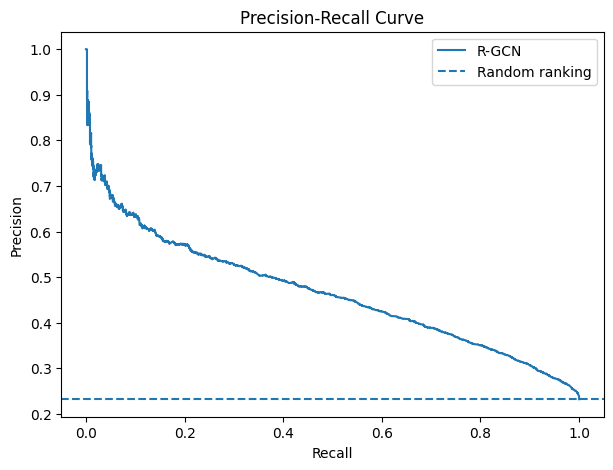

In [27]:
# Precision-recall curves.

plt.figure(figsize=(7, 5))

for model_name, probability_column in {
    "R-GCN": "rgcn_probability",
}.items():

    precision, recall, _ = precision_recall_curve(
        y_true,
        evaluation[probability_column]
    )

    plt.plot(
        recall,
        precision,
        label=model_name
    )

plt.axhline(
    y=evaluation["target"].mean(),
    linestyle="--",
    label="Random ranking"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


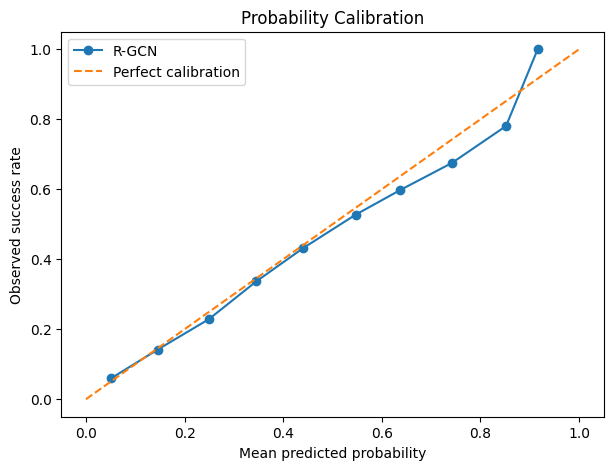

In [28]:
# Calibration curves.

from sklearn.calibration import calibration_curve

plt.figure(figsize=(7, 5))

for model_name, probability_column in {
    "R-GCN": "rgcn_probability",
}.items():

    observed_rate, predicted_probability = calibration_curve(
        y_true,
        evaluation[probability_column],
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        predicted_probability,
        observed_rate,
        marker="o",
        label=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed success rate")
plt.title("Probability Calibration")
plt.legend()
plt.show()


## 8. Save evaluation outputs


In [29]:
# Save the compact outputs used in the Part C write-up.

evaluation.to_csv(
    "evaluation_predictions.csv",
    index=False
)

model_metrics.to_csv(
    "model_metrics.csv"
)